In [1]:
import h5py

file_path = "/kaggle/input/datasets/happysaxena/cern-labelled-2/Dataset_Specific_labelled_full_only_for_2i.h5"

with h5py.File(file_path, 'r') as f:
    print("Keys:", list(f.keys()))

Keys: ['Y', 'jet', 'm', 'pT']


In [2]:
import numpy as np
with h5py.File(file_path, 'r') as f:
    
    y = f['Y'][:]
    jet = f['jet'][:]
    m = f['m'][:]
    pt = f['pT'][:]
    

In [3]:
classes = np.unique(y)
classes2 = np.unique(m)
classes3 = np.unique(pt)
print("Classes:", classes)
print("classes2 : ",classes2)
print("classes3 : ",classes3)

print(y.shape)
print(m[0])
print(pt[0])

Classes: [0. 1.]
classes2 :  [ 31.948496  37.162827  37.652603 ... 546.1223   584.933    728.3518  ]
classes3 :  [ 400.01608  400.04034  400.05087 ... 1437.8463  1456.0001  2039.6335 ]
(10000, 1)
[136.34013]
[551.3493]


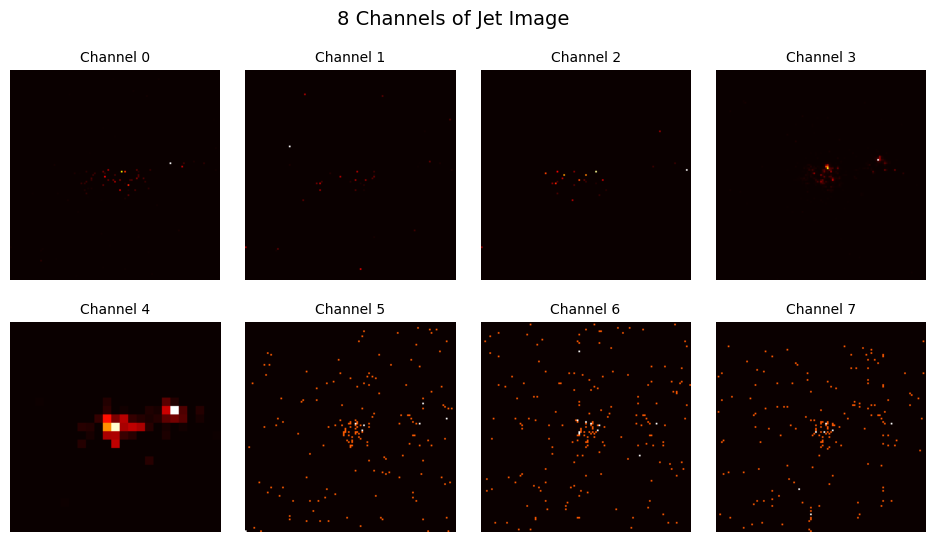

In [4]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = 5

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):
    ax = axes[i // 4, i % 4]
    
    img = jet[sample_idx, :, :, i]   # ✅ correct slicing
    
    # ax.imshow(img, cmap='viridis', aspect='equal')
    ax.imshow(img, cmap='hot', aspect='equal')
    ax.set_title(f'Channel {i}', fontsize=10)
    ax.axis('off')

plt.suptitle("8 Channels of Jet Image", fontsize=14)
plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.show()

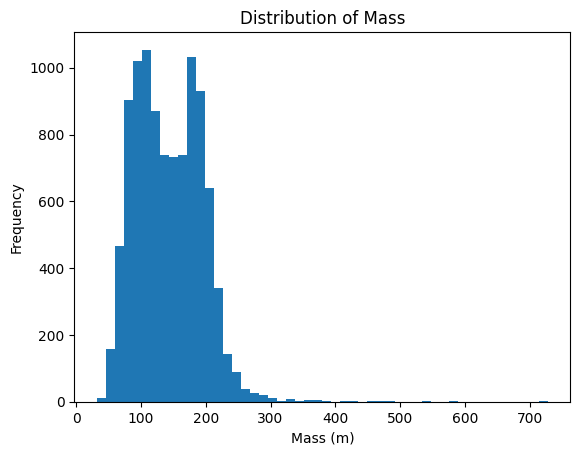

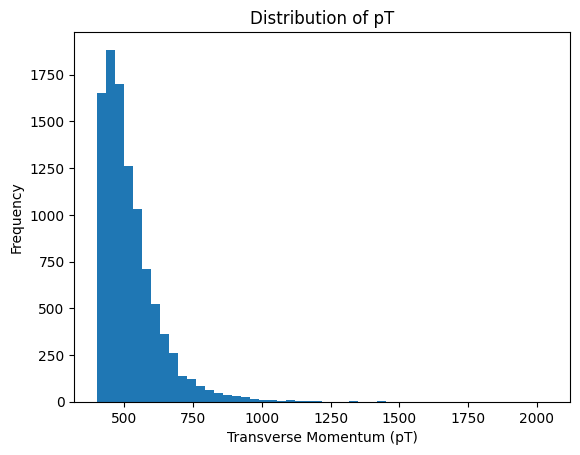

In [5]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

with h5py.File(file_path, 'r') as f:
    y = f['Y'][:]
    jet = f['jet'][:]
    m = f['m'][:]
    pt = f['pT'][:]

# ---- Histogram for Mass ----
plt.figure()
plt.hist(m, bins=50)
plt.xlabel("Mass (m)")
plt.ylabel("Frequency")
plt.title("Distribution of Mass")
plt.show()

# ---- Histogram for pT ----
plt.figure()
plt.hist(pt, bins=50)
plt.xlabel("Transverse Momentum (pT)")
plt.ylabel("Frequency")
plt.title("Distribution of pT")
plt.show()

In [6]:
print(jet.shape)

(10000, 125, 125, 8)


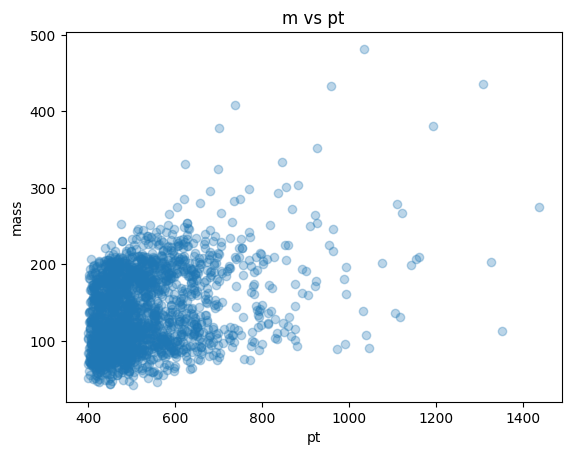

In [7]:
plt.scatter(pt[:2000], m[:2000], alpha=0.3)
plt.xlabel("pt")
plt.ylabel("mass")
plt.title("m vs pt")
plt.show()

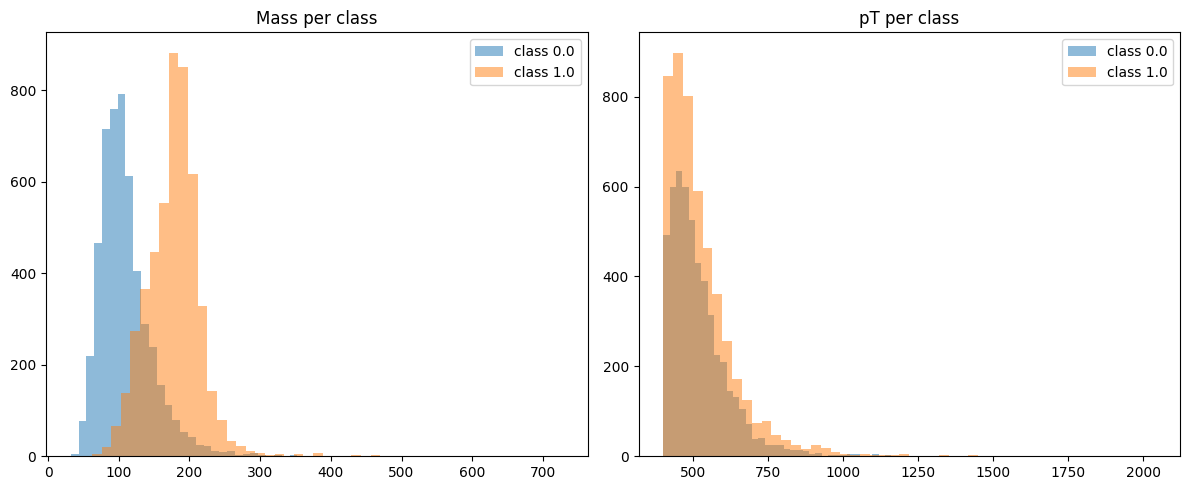

In [8]:
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# --- Mass plot ---
for c in classes:
    axes[0].hist(m[y.squeeze() == c], bins=50, alpha=0.5, label=f'class {c}')
axes[0].set_title("Mass per class")
axes[0].legend()

# --- pT plot ---
for c in classes:
    axes[1].hist(pt[y.squeeze() == c], bins=50, alpha=0.5, label=f'class {c}')
axes[1].set_title("pT per class")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
channel_energy = jet.sum(axis=(0,1,2))
print(channel_energy)

[1.2072771e+07 1.3113787e+07 8.8730740e+06 1.9936956e+07 2.3095142e+08
 1.7363082e+08 1.8152278e+08 1.7501650e+08]


In [10]:
for i in range(8):
    sparsity = np.count_nonzero(jet[:,:,:,i]) / jet[:,:,:,i].size
    print(f"Channel {i}: {sparsity}")

Channel 0: 0.0034099968
Channel 1: 0.0016168
Channel 2: 0.0009856832
Channel 3: 0.0147199296
Channel 4: 0.04905056
Channel 5: 0.0086852736
Channel 6: 0.0102258048
Channel 7: 0.01038064


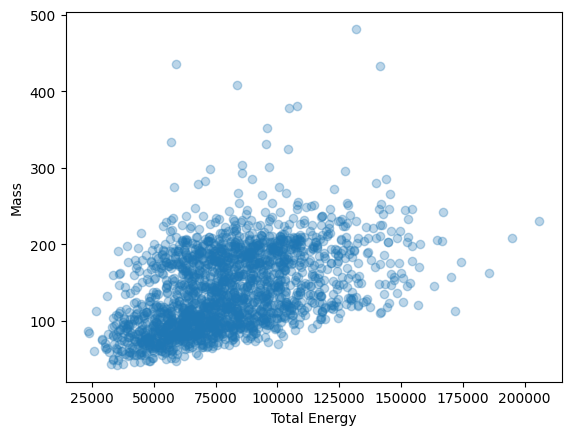

In [11]:
total_energy = jet.sum(axis=(1,2,3))

plt.scatter(total_energy[:2000], m[:2000], alpha=0.3)
plt.xlabel("Total Energy")
plt.ylabel("Mass")
plt.show()

In [12]:
print("Mass range:", m.min(), m.max())
print("pt range:", pt.min(), pt.max())

Mass range: 31.948496 728.3518
pt range: 400.01608 2039.6335


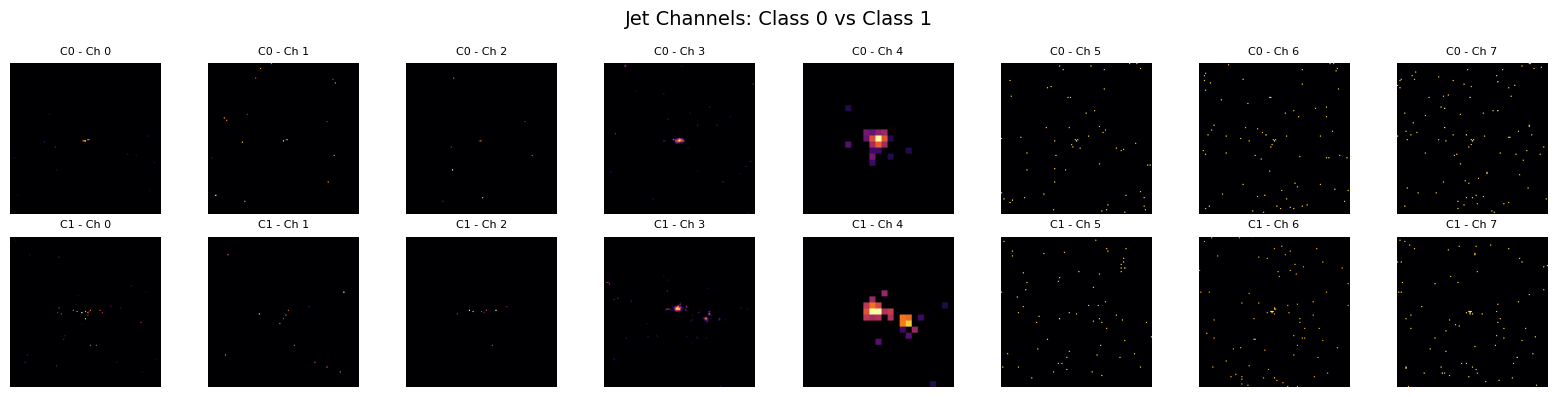

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- find one sample for each class ---
idx_0 = np.where(y.squeeze() == 0)[0][0]
idx_1 = np.where(y.squeeze() == 1)[0][0]

img_0 = jet[idx_0]   # shape (125, 125, 8)
img_1 = jet[idx_1]

# --- plot ---
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    # Class 0
    axes[0, i].imshow(np.log1p(img_0[:, :, i]), cmap='inferno', aspect='equal')
    axes[0, i].set_title(f'C0 - Ch {i}', fontsize=8)
    axes[0, i].axis('off')
    
    # Class 1
    axes[1, i].imshow(np.log1p(img_1[:, :, i]), cmap='inferno', aspect='equal')
    axes[1, i].set_title(f'C1 - Ch {i}', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle("Jet Channels: Class 0 vs Class 1", fontsize=14)
plt.tight_layout()
plt.show()